# Quantum Optical Reservoir Computing (QORC) with MerLin

This notebook is a first practical introduction to **quantum optical reservoir computing** inspired by:

- [**Quantum optical reservoir computing powered by boson sampling**](https://opg.optica.org/opticaq/fulltext.cfm?uri=opticaq-3-3-238), Sakurai et al., (2025)
- [**Photonic Quantum-Accelerated Machine Learning**](https://arxiv.org/abs/2512.08318), Rambach et al., (2025)

Goals:

1. Explain the reservoir structure and intuition.
2. Build a first reservoir with `QuantumLayer.simple()`.
3. Build a reservoir with the same fixed Haar-random unitary used **before and after** encoding.
4. Evaluate it and compare against classical baselines.

## 1) Reservoir computing intuition

![Quantum optical reservoir scheme](../_static/img/reservoir_scheme.png)


Reservoir computing separates the model into two parts:

- **Reservoir (A)**: a fixed nonlinear feature map (not trained).
- **Readout**: a small trainable classical model (often linear).

If we look at the image above, we could have 3 ways to classify the images:
- Option A: a fixed Boson Sampler applied to a specific input (PCA components or raw inputs, depending on the input size and the experiment). The output of this Boson Sampler is fed to a trainable Linear layer that maps it to the correct output (here, the classes)
- Option B: the image is directly fed to the Linear layer and we operate a linear classification
- Option C (and the case in the 2 papers mentioned): the input to the linear readout is the concatenation of the quantum features and the raw (flattened) input

NOTE: we can imagine using another kind of readout (MLP, CNN). For the purpose of this tutorial and because it is used in the 2 papers, we use a linear readout.

Why this is useful:

- training is simpler and faster (few trainable parameters),
- nonlinear dynamics in the reservoir can lift data into a richer feature space.

In a photonic quantum setting, the reservoir is a fixed interferometer + encoding + measurement pipeline.

Before diving in this tutorial, let's import all necessary tools:

In [1]:
import sys
from pathlib import Path

# Force the notebook to import the local source tree before any installed wheel.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'merlin' / 'models' / 'reservoir_classifier.py').exists():
        repo_root = candidate
        break
else:
    repo_root = None

if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import merlin as ML
import perceval as pcvl
from perceval.components import BS, PS

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

## 2) Experimental setup

### 2.1) Loading a simple dataset

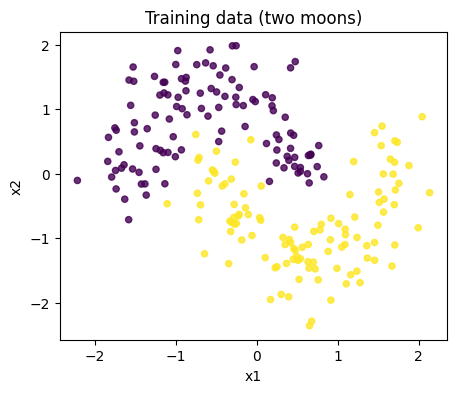

In [2]:
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_dataset(seed=SEED):
    X, y = make_moons(n_samples=320, noise=0.20, random_state=seed)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return (
        X_train.astype(np.float32),
        X_test.astype(np.float32),
        y_train.astype(np.int64),
        y_test.astype(np.int64),
    )


X_train, X_test, y_train, y_test = make_dataset()

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, alpha=0.8)
plt.title("Training data (two moons)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### 2.2) QOR structure used here

We use the following pattern:

1. fixed interferometer `U` (mixing stage),
2. data encoding `E(x)` (phase shifts from input features),
3. the **same** fixed interferometer `U` again,
4. photonic measurement gives reservoir features,
5. as mentioned above, we train a classical readout on top.

This follows the common "fixed random optical map + trainable readout" idea used in QOR works.

### Note on PCA

In the MNIST experiments from the referenced papers, PCA is often applied before encoding to reduce dimensionality.

For this notebook we use two-moons (2 features), so PCA is not necessary.

If you later switch this notebook to image datasets (e.g., MNIST), adding a PCA preprocessing block is recommended for a fair protocol match.


## 3) Classical baselines

We train two standard baselines:

- Logistic Regression
- 1-hidden-layer MLP

In [3]:
def run_classical_baselines(X_train, y_train, X_test, y_test):
    results = []

    baselines = {
        "LogReg": LogisticRegression(max_iter=1000, random_state=SEED),
        "MLP(16)": MLPClassifier(
            hidden_layer_sizes=(16,), max_iter=1200, random_state=SEED
        ),
    }

    for name, model in baselines.items():
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        dt = time.perf_counter() - t0

        y_pred = model.predict(X_test)
        results.append({
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "train_time_s": dt,
        })

    return results


classical_results = run_classical_baselines(X_train, y_train, X_test, y_test)
pd.DataFrame(classical_results)

,model,accuracy,f1,train_time_s
0,LogReg,0.802083,0.808081,0.009799
1,MLP(16),0.916667,0.918367,0.220464


## 4) Shared helper: cached reservoir features + trainable linear readout

In the referenced QOR workflows, the readout input is the concatenation `[x, r(x)]`.

For efficiency, we compute `r(x)` once, cache it, then train only a linear readout on cached features.


In [4]:
def compute_reservoir_features(reservoir, X, batch_size=128):
    reservoir.requires_grad_(False)
    reservoir.eval()

    X_tensor = torch.tensor(X, dtype=torch.float32)
    chunks = []

    with torch.no_grad():
        for start in range(0, len(X_tensor), batch_size):
            xb = X_tensor[start : start + batch_size]
            rb = reservoir(xb)
            chunks.append(rb)

    return torch.cat(chunks, dim=0)


def make_concat_features(reservoir, X):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    R_tensor = compute_reservoir_features(reservoir, X)
    return torch.cat([X_tensor, R_tensor], dim=1)


def train_linear_readout_from_features(
    F_train, y_train, F_test, y_test, epochs=200, lr=0.05
):
    ytr = torch.tensor(y_train, dtype=torch.long)
    yte = torch.tensor(y_test, dtype=torch.long)
    n_classes = int(np.max(y_train)) + 1

    readout = nn.Linear(F_train.shape[1], n_classes)
    optimizer = torch.optim.Adam(readout.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    # Track training history
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    t0 = time.perf_counter()
    readout.train()
    for epoch in range(epochs):
        # Training step
        optimizer.zero_grad()
        logits = readout(F_train)
        loss = loss_fn(logits, ytr)
        loss.backward()
        optimizer.step()

        # Track metrics every epoch
        readout.eval()
        with torch.no_grad():
            # Train metrics
            train_logits = readout(F_train)
            train_loss = loss_fn(train_logits, ytr).item()
            train_pred = train_logits.argmax(dim=1).cpu().numpy()
            train_acc = accuracy_score(y_train, train_pred)

            # Val metrics
            val_logits = readout(F_test)
            val_loss = loss_fn(val_logits, yte).item()
            val_pred = val_logits.argmax(dim=1).cpu().numpy()
            val_acc = accuracy_score(y_test, val_pred)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        readout.train()

    dt = time.perf_counter() - t0

    readout.eval()
    with torch.no_grad():
        y_pred = readout(F_test).argmax(dim=1).cpu().numpy()

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "train_time_s": dt,
        "history": history,
    }

## 5) First reservoir with `QuantumLayer.simple()`

This gives a quick fixed photonic feature map. We explicitly choose the computation space in the current API, then learn only the readout.

In [5]:
simple_reservoir = ML.QuantumLayer.simple(
    input_size=2,
    computation_space=ML.ComputationSpace.UNBUNCHED,
)

F_train_simple = make_concat_features(simple_reservoir, X_train)
F_test_simple = make_concat_features(simple_reservoir, X_test)

simple_metrics = train_linear_readout_from_features(
    F_train_simple, y_train, F_test_simple, y_test, epochs=240, lr=0.01
)

print(
    f"Results: Accuracy {simple_metrics['accuracy']:.4f}, F1 {simple_metrics['f1']:.4f}, Train time {simple_metrics['train_time_s']:.2f}s"
)

/var/folders/g5/xyqwmpys7177hgy25td4j6740000gn/T/ipykernel_89624/375005998.py:1: DeprecationWarning: Parameter 'computation_space' is deprecated. The 'computation_space' keyword is deprecated; move it into MeasurementStrategy.probs(computation_space).
  simple_reservoir = ML.QuantumLayer.simple(


Results: Accuracy 0.7812, F1 0.7921, Train time 0.18s


## 6) ReservoirClassifier directly on the 2D input

Instead of manually building a custom `QuantumLayer`, we can use the higher-level `ReservoirClassifier` API.

For the two-moons dataset we keep the original 2 features and feed them directly to `ReservoirClassifier`. Without a reduction step, the reservoir therefore stays a true 2-mode photonic model.

In [6]:
def make_reservoir_classifier_inputs(X_train, X_test):
    return X_train.astype(np.float32), X_test.astype(np.float32)


def train_reservoir_classifier(model, X_train, y_train, X_test, y_test, epochs=240, lr=0.01):
    model.fit_reservoir(X_train)
    F_train, ytr = model.make_dataset(X_train, y_train).tensors
    F_test, yte = model.make_dataset(X_test, y_test).tensors

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    t0 = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(F_train)
        loss = loss_fn(logits, ytr)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(F_train)
            val_logits = model(F_test)
            history['train_loss'].append(loss_fn(train_logits, ytr).item())
            history['val_loss'].append(loss_fn(val_logits, yte).item())
            history['train_acc'].append(accuracy_score(y_train, train_logits.argmax(dim=1).cpu().numpy()))
            history['val_acc'].append(accuracy_score(y_test, val_logits.argmax(dim=1).cpu().numpy()))

    dt = time.perf_counter() - t0
    y_pred = model.predict(X_test).argmax(dim=1).cpu().numpy()

    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'train_time_s': dt,
        'history': history,
    }


X_train_reservoir, X_test_reservoir = make_reservoir_classifier_inputs(X_train, X_test)

reservoir_classifier = ML.ReservoirClassifier(
    in_features=X_train_reservoir.shape[1],
    out_features=2,
    n_photons=2,
    concatenate=True,
    cache=True,
    seed=SEED,
    dtype=torch.float32,
)
reservoir_classifier.layer.measurement_strategy = ML.MeasurementStrategy.probs(
    computation_space=ML.ComputationSpace.UNBUNCHED,
)

reservoir_classifier_metrics = train_reservoir_classifier(
    reservoir_classifier,
    X_train_reservoir,
    y_train,
    X_test_reservoir,
    y_test,
    epochs=320,
    lr=0.02,
)

print(f"Input width: {X_train_reservoir.shape[1]}")
print(
    f"Reservoir modes: {reservoir_classifier.layer.n_modes}, "
    f"quantum output size: {reservoir_classifier.layer.output_size}, "
    f"readout input width: {reservoir_classifier.readout.in_features}"
)
print(
    f"Results: Accuracy {reservoir_classifier_metrics['accuracy']:.4f}, "
    f"F1 {reservoir_classifier_metrics['f1']:.4f}, "
    f"Train time {reservoir_classifier_metrics['train_time_s']:.2f}s"
)

Input width: 2
Reservoir modes: 2, quantum output size: 1, readout input width: 3
Results: Accuracy 0.8021, F1 0.8081, Train time 0.17s


## 7) Compare all models

In [7]:
all_results = []
all_results.extend(classical_results)

all_results.append({
    "model": "MerLin simple",
    **simple_metrics,
})

all_results.append({
    'model': 'ReservoirClassifier (2 features)',
    **reservoir_classifier_metrics,
})

results_df = pd.DataFrame(all_results).sort_values(by="accuracy", ascending=False)
results_df

,model,accuracy,f1,train_time_s,history
1,MLP(16),0.916667,0.918367,0.220464,NaN
0,LogReg,0.802083,0.808081,0.009799,NaN
3,ReservoirClassifier (2 features),0.802083,0.808081,0.174888,"{'train_loss': [0.6682752966880798, 0.64041745..."
2,MerLin simple,0.781250,0.792079,0.181588,"{'train_loss': [0.8916221261024475, 0.87204307..."


In [8]:
def plot_training_curves(history, title):
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot loss
    axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot accuracy
    axes[1].plot(history["train_acc"], label="Train Accuracy", linewidth=2)
    axes[1].plot(history["val_acc"], label="Val Accuracy", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

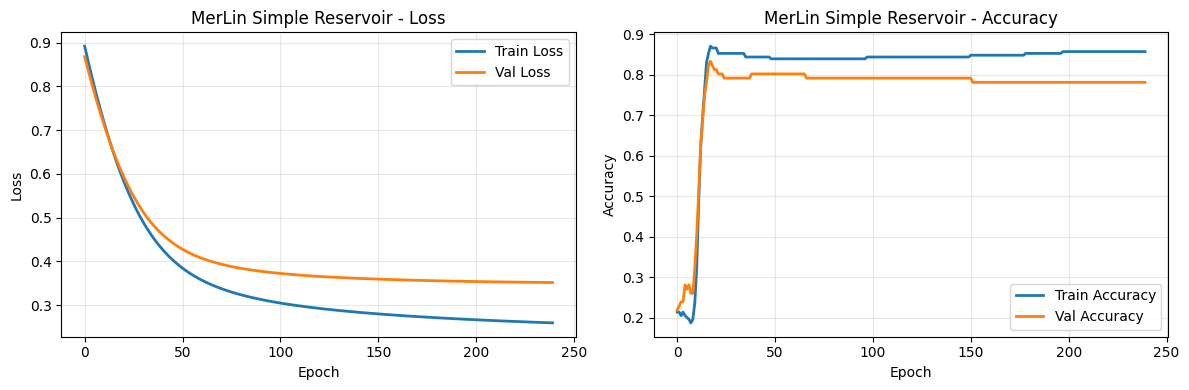

In [9]:
plot_training_curves(simple_metrics["history"], "MerLin Simple Reservoir")

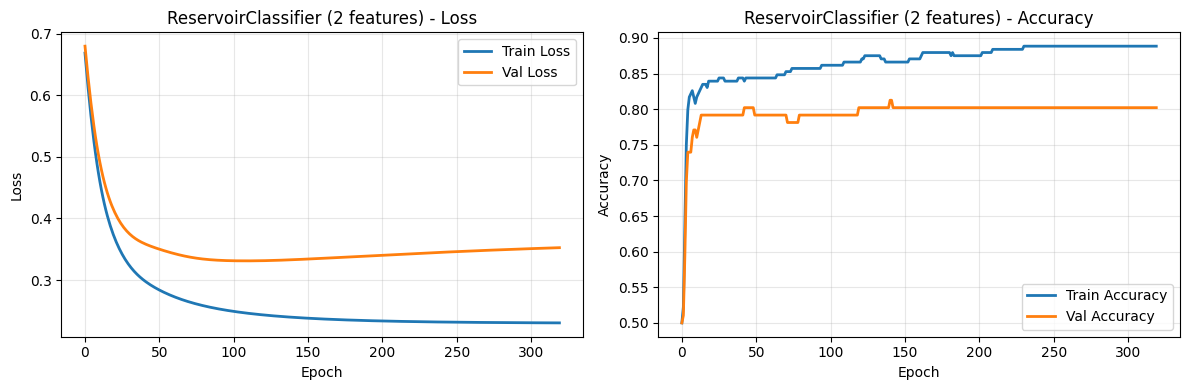

In [10]:
plot_training_curves(reservoir_classifier_metrics['history'], 'ReservoirClassifier (2 features)')


### Analysis

**Accuracy Performance:**

Looking at the results above, we compare the models on the Moon dataset:

- **LogReg**: Linear baseline with relatively low accuracy due to the non-linearity of the problem.
- **MLP(16)**: Classical neural network with one hidden layer achieves good accuracy.
- **MerLin simple**: Fixed photonic feature map provides non-linear features for the linear readout.
- **ReservoirClassifier (2 features)**: the built-in frozen photonic reservoir is applied directly to the original two-moons coordinates, with a trainable readout on top.

**Overfitting Analysis:**

From the training curves, we observe:

- **Simple Reservoir**: Shows clear **overfitting** — the training loss continues to decrease while validation loss increases or plateaus. The gap between red and blue lines in the accuracy plot widens, indicating the model is memorizing training data rather than generalizing.

- **ReservoirClassifier**: typically gives smoother optimization because the reservoir features are standardized internally and the readout is trained on a fixed cached feature tensor.

This demonstrates how the higher-level `ReservoirClassifier` API can replace custom circuit plumbing while keeping the same frozen-reservoir workflow.

**Training Time:**

- Classical methods (LogReg, MLP) train in **milliseconds**, as they operate on raw inputs.
- Quantum reservoirs require **computing reservoir features** (photonic simulation) for each input, making them slower. The `ReservoirClassifier` and simple reservoir examples are dominated by readout training once the features are cached.
- In a practical photonic setting, the reservoir computation would be parallelized on dedicated hardware, closing this gap.

**Key Takeaways:**

1. The higher-level `ReservoirClassifier` API is enough for a complete frozen-reservoir workflow on this task.
2. On this toy dataset, skipping PCA keeps the example aligned with the original 2-feature input and makes the reservoir structure easier to interpret.
3. For real quantum hardware, the speedup would be more pronounced, as photonic operations execute in constant time regardless of feature space dimensionality.

## 8) Sensitivity to the number of photons in a 2-mode reservoir

In this example we keep the raw 2-feature input and leave the reservoir at 2 modes. A meaningful knob to vary is therefore the number of photons in the input state.

If you manually increase `layer.n_modes`, only the first encoded input modes receive phase shifters, while the extra modes remain available for the interferometer dynamics.


Circuit with 3 modes and 1 photons:
Circuit with 3 modes and 2 photons:


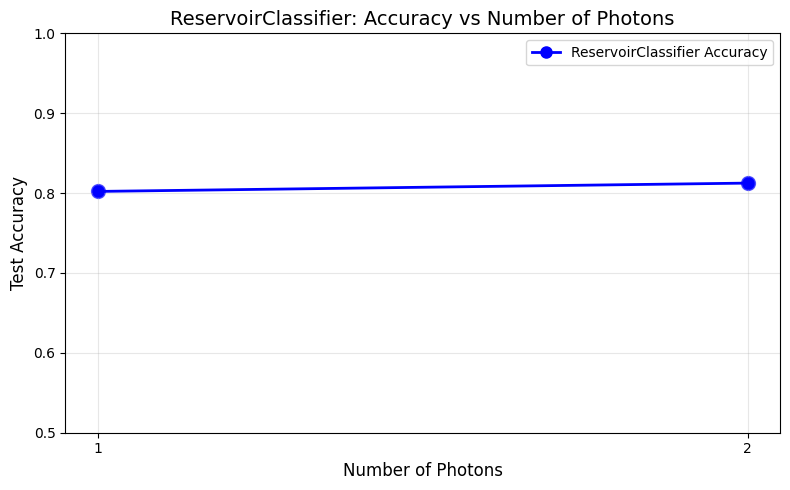


Accuracy by photon count:
  1 photons: 0.8021
  2 photons: 0.8125


In [16]:
SEED = 16
all_photons = [1, 2]
accuracies = {}
for n_photons in all_photons:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    X_train_reservoir, X_test_reservoir = make_reservoir_classifier_inputs(X_train, X_test)

    model = ML.ReservoirClassifier(
        in_features=X_train_reservoir.shape[1],
        out_features=2,
        n_photons=n_photons,
        concatenate=True,
        cache=True,
        seed=SEED,
        dtype=torch.float32,
    )
    model.layer.measurement_strategy = ML.MeasurementStrategy.probs(
        computation_space=ML.ComputationSpace.UNBUNCHED,
    )
    model.layer.n_modes = 4
    print(f"Circuit with {model.layer.n_modes} modes and {n_photons} photons:")
    pcvl.pdisplay(model.layer.circuit)

    metrics = train_reservoir_classifier(
        model,
        X_train_reservoir,
        y_train,
        X_test_reservoir,
        y_test,
        epochs=240,
        lr=0.02,
    )
    accuracies[str(n_photons)] = metrics['accuracy']

photons = [int(k) for k in accuracies.keys()]
accs = [accuracies[k] for k in sorted(accuracies.keys(), key=lambda x: int(x))]

plt.figure(figsize=(8, 5))
plt.plot(photons, accs, marker='o', linewidth=2, markersize=8, color='blue', label='ReservoirClassifier Accuracy')
plt.scatter(photons, accs, s=100, color='blue', alpha=0.6)
plt.xlabel('Number of Photons', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('ReservoirClassifier: Accuracy vs Number of Photons', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(photons)
plt.ylim([0.5, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nAccuracy by photon count:")
for n_photons in sorted(photons):
    print(f"  {n_photons} photons: {accuracies[str(n_photons)]:.4f}")


**Interpretation**: the performance increases with the size of the Fock space.

## 9) Interpretation and next step

What to look for:

- If `ReservoirClassifier` beats the simple reservoir, the fixed haar-random interferometer likely produced a better photonic feature map directly from the 2D input.
- If a classical MLP still wins, that is normal on small toy data; the goal here is to validate the frozen-reservoir pipeline and evaluation protocol.

We invite you to:

1. repeat runs over multiple random seeds,
2. observe the sensitivity to `n_photons`, the measurement strategy, and the random seed,
3. replace synthetic data with a target dataset from your project,
4. richer readouts (ridge/logistic) and regularization.